# EDA — ChurnGuard : Dataset Rivalytics

**5 tables** : accounts, subscriptions, feature_usage, churn_events, support_tickets  
**Target** : `churn_flag` dans `rivalytics_accounts`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

matplotlib.rcParams['figure.figsize'] = (10, 4)
DATA_DIR = Path('../data')

accounts       = pd.read_csv(DATA_DIR / 'rivalytics_accounts.csv')
subscriptions  = pd.read_csv(DATA_DIR / 'rivalytics_subscriptions.csv')
feature_usage  = pd.read_csv(DATA_DIR / 'rivalytics_feature_usage.csv')
churn_events   = pd.read_csv(DATA_DIR / 'rivalytics_churn_events.csv')
support_tickets = pd.read_csv(DATA_DIR / 'rivalytics_support_tickets.csv')

print('accounts      :', accounts.shape)
print('subscriptions :', subscriptions.shape)
print('feature_usage :', feature_usage.shape)
print('churn_events  :', churn_events.shape)
print('support_tickets:', support_tickets.shape)

accounts      : (500, 10)
subscriptions : (5000, 14)
feature_usage : (25000, 8)
churn_events  : (600, 9)
support_tickets: (2000, 9)


---
## 1. Distribution de la target

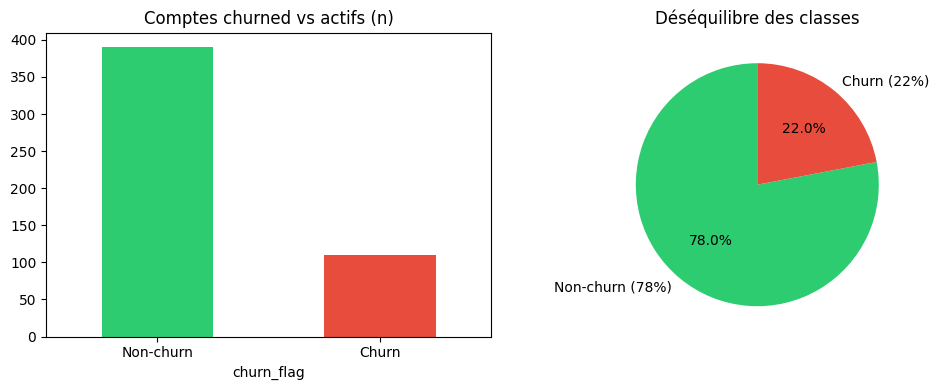

Churn : 22% — déséquilibre modéré → class_weight="balanced" suffira probablement (SMOTE si F1 < 0.70)


In [2]:
churn_counts = accounts['churn_flag'].value_counts()
churn_pct    = accounts['churn_flag'].value_counts(normalize=True).round(3) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
churn_counts.plot.bar(ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Comptes churned vs actifs (n)')
axes[0].set_xticklabels(['Non-churn', 'Churn'], rotation=0)

churn_pct.plot.pie(ax=axes[1], labels=['Non-churn (78%)', 'Churn (22%)'],
                   colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Déséquilibre des classes')
plt.tight_layout()
plt.show()

print('Churn : 22% — déséquilibre modéré → class_weight="balanced" suffira probablement (SMOTE si F1 < 0.70)')

---
## 2. Table `rivalytics_accounts`

In [3]:
print('Shape :', accounts.shape)
print('Nulls :')
print(accounts.isnull().sum())
accounts.head()

Shape : (500, 10)
Nulls :
account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


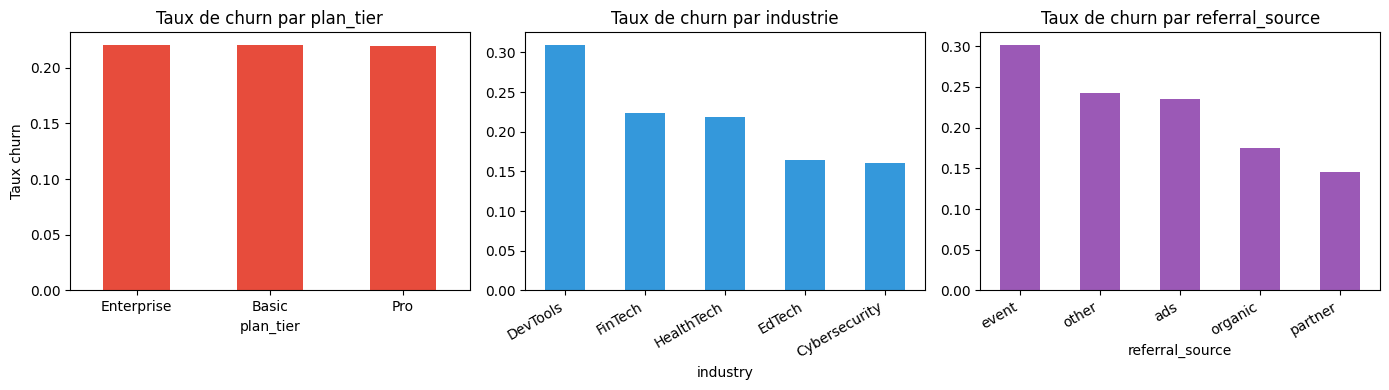

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Churn par plan_tier
churn_by_plan = accounts.groupby('plan_tier')['churn_flag'].mean().sort_values(ascending=False)
churn_by_plan.plot.bar(ax=axes[0], color='#e74c3c')
axes[0].set_title('Taux de churn par plan_tier')
axes[0].set_ylabel('Taux churn')
axes[0].set_xticklabels(churn_by_plan.index, rotation=0)

# Churn par industry
churn_by_industry = accounts.groupby('industry')['churn_flag'].mean().sort_values(ascending=False)
churn_by_industry.plot.bar(ax=axes[1], color='#3498db')
axes[1].set_title('Taux de churn par industrie')
axes[1].set_xticklabels(churn_by_industry.index, rotation=30, ha='right')

# Churn par referral_source
churn_by_ref = accounts.groupby('referral_source')['churn_flag'].mean().sort_values(ascending=False)
churn_by_ref.plot.bar(ax=axes[2], color='#9b59b6')
axes[2].set_title('Taux de churn par referral_source')
axes[2].set_xticklabels(churn_by_ref.index, rotation=30, ha='right')

plt.tight_layout()
plt.show()

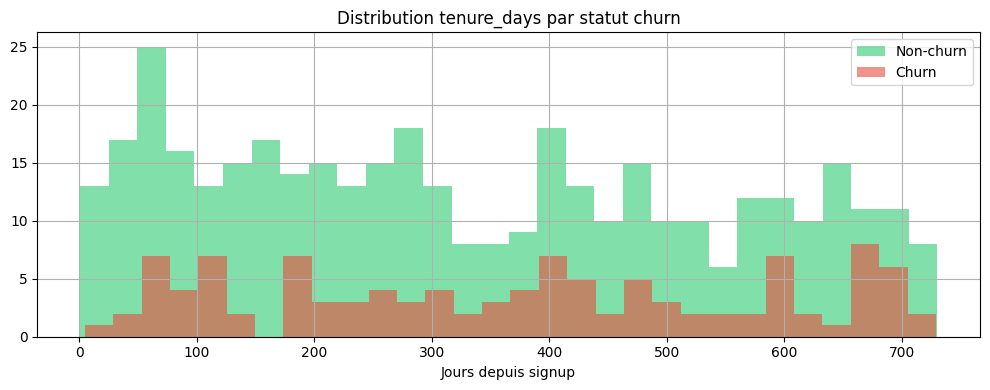

Médiane tenure (non-churn): 302.0
Médiane tenure (churn): 380.5


In [5]:
# Tenure : durée depuis signup
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
reference_date = pd.Timestamp('2025-01-01')  # date de référence dataset
accounts['tenure_days'] = (reference_date - accounts['signup_date']).dt.days

fig, ax = plt.subplots(figsize=(10, 4))
for churn_val, label, color in [(False, 'Non-churn', '#2ecc71'), (True, 'Churn', '#e74c3c')]:
    accounts[accounts['churn_flag'] == churn_val]['tenure_days'].hist(
        bins=30, ax=ax, alpha=0.6, label=label, color=color
    )
ax.set_title('Distribution tenure_days par statut churn')
ax.set_xlabel('Jours depuis signup')
ax.legend()
plt.tight_layout()
plt.show()

print('Médiane tenure (non-churn):', accounts[~accounts['churn_flag']]['tenure_days'].median())
print('Médiane tenure (churn):', accounts[accounts['churn_flag']]['tenure_days'].median())

---
## 3. Table `rivalytics_subscriptions`

In [6]:
print('Shape :', subscriptions.shape)
print('Nulls :')
print(subscriptions.isnull().sum())
subscriptions.head()

Shape : (5000, 14)
Nulls :
subscription_id         0
account_id              0
start_date              0
end_date             4514
plan_tier               0
seats                   0
mrr_amount              0
arr_amount              0
is_trial                0
upgrade_flag            0
downgrade_flag          0
churn_flag              0
billing_frequency       0
auto_renew_flag         0
dtype: int64


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


Abonnements actifs (end_date null): 4514
Trials (mrr_amount=0): 778
Avec upgrade : 529
Avec downgrade : 218


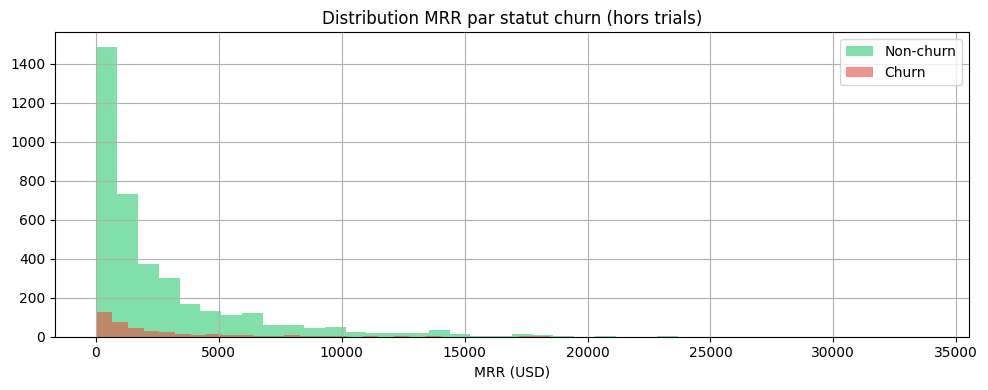

In [7]:
print('Abonnements actifs (end_date null):', subscriptions['end_date'].isna().sum())
print('Trials (mrr_amount=0):', (subscriptions['mrr_amount'] == 0).sum())
print('Avec upgrade :', subscriptions['upgrade_flag'].sum())
print('Avec downgrade :', subscriptions['downgrade_flag'].sum())

# Distribution MRR (hors trials)
sub_paid = subscriptions[subscriptions['mrr_amount'] > 0]
fig, ax = plt.subplots(figsize=(10, 4))
for churn_val, label, color in [(False, 'Non-churn', '#2ecc71'), (True, 'Churn', '#e74c3c')]:
    sub_paid[sub_paid['churn_flag'] == churn_val]['mrr_amount'].hist(
        bins=40, ax=ax, alpha=0.6, label=label, color=color
    )
ax.set_title('Distribution MRR par statut churn (hors trials)')
ax.set_xlabel('MRR (USD)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Table `rivalytics_feature_usage`

In [8]:
print('Shape :', feature_usage.shape)
print('Features uniques :', feature_usage['feature_name'].nunique())
print('Nulls :')
print(feature_usage.isnull().sum())
print()
print('error_count > 0 :', (feature_usage['error_count'] > 0).sum(), '/', len(feature_usage))
print('beta sessions :', feature_usage['is_beta_feature'].sum(), '/', len(feature_usage))
feature_usage.head()

Shape : (25000, 8)
Features uniques : 40
Nulls :
usage_id               0
subscription_id        0
usage_date             0
feature_name           0
usage_count            0
usage_duration_secs    0
error_count            0
is_beta_feature        0
dtype: int64

error_count > 0 : 7731 / 25000
beta sessions : 2544 / 25000


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


Médiane error_rate (non-churn): 0.055
Médiane error_rate (churn): 0.0537


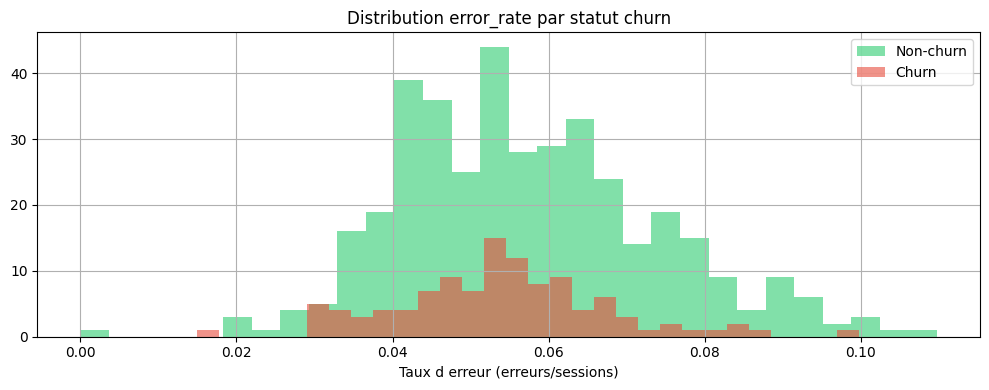

In [9]:
# Agréger par subscription pour joindre avec churn_flag
fu_with_churn = feature_usage.merge(
    subscriptions[['subscription_id', 'account_id', 'churn_flag']],
    on='subscription_id', how='left'
).merge(accounts[['account_id', 'churn_flag']].rename(columns={'churn_flag': 'account_churn'}),
        on='account_id', how='left')

# error_rate vs churn (agrégé par account)
usage_per_account = fu_with_churn.groupby(['account_id', 'account_churn']).agg(
    total_errors=('error_count', 'sum'),
    total_sessions=('usage_count', 'sum')
).reset_index()
usage_per_account['error_rate'] = usage_per_account['total_errors'] / usage_per_account['total_sessions'].replace(0, 1)

print('Médiane error_rate (non-churn):', usage_per_account[~usage_per_account['account_churn']]['error_rate'].median().round(4))
print('Médiane error_rate (churn):', usage_per_account[usage_per_account['account_churn']]['error_rate'].median().round(4))

fig, ax = plt.subplots(figsize=(10, 4))
for churn_val, label, color in [(False, 'Non-churn', '#2ecc71'), (True, 'Churn', '#e74c3c')]:
    usage_per_account[usage_per_account['account_churn'] == churn_val]['error_rate'].hist(
        bins=30, ax=ax, alpha=0.6, label=label, color=color
    )
ax.set_title('Distribution error_rate par statut churn')
ax.set_xlabel('Taux d erreur (erreurs/sessions)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Table `rivalytics_churn_events`

In [10]:
print('Shape :', churn_events.shape)
print('is_reactivation:', churn_events['is_reactivation'].value_counts().to_dict())
churn_events.head()

Shape : (600, 9)
is_reactivation: {False: 539, True: 61}


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


Événements réels de churn (hors réactivation) : 539
Comptes uniques avec churn event : 339


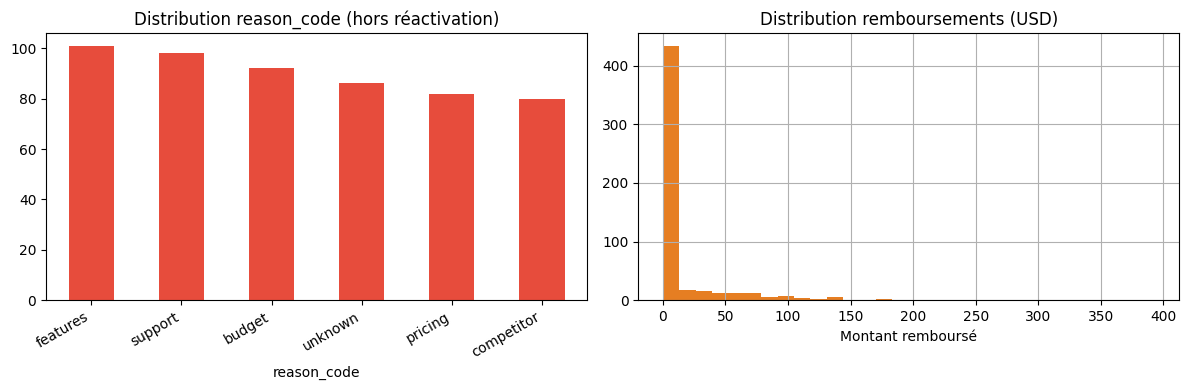

preceding_downgrade avant churn : 45 / 539


In [11]:
# Filtrage réactivations (double-comptage)
ce_clean = churn_events[churn_events['is_reactivation'] == False]
print('Événements réels de churn (hors réactivation) :', len(ce_clean))
print('Comptes uniques avec churn event :', ce_clean['account_id'].nunique())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ce_clean['reason_code'].value_counts().plot.bar(ax=axes[0], color='#e74c3c')
axes[0].set_title('Distribution reason_code (hors réactivation)')
axes[0].set_xticklabels(ce_clean['reason_code'].value_counts().index, rotation=30, ha='right')

ce_clean['refund_amount_usd'].hist(bins=30, ax=axes[1], color='#e67e22')
axes[1].set_title('Distribution remboursements (USD)')
axes[1].set_xlabel('Montant remboursé')

plt.tight_layout()
plt.show()

print('preceding_downgrade avant churn :', ce_clean['preceding_downgrade_flag'].sum(), '/', len(ce_clean))

---
## 6. Table `rivalytics_support_tickets`

In [12]:
print('Shape :', support_tickets.shape)
print('Nulls :')
print(support_tickets.isnull().sum())
support_tickets.head()

Shape : (2000, 9)
Nulls :
ticket_id                        0
account_id                       0
submitted_at                     0
closed_at                        0
resolution_time_hours            0
priority                         0
first_response_time_minutes      0
satisfaction_score             825
escalation_flag                  0
dtype: int64


,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


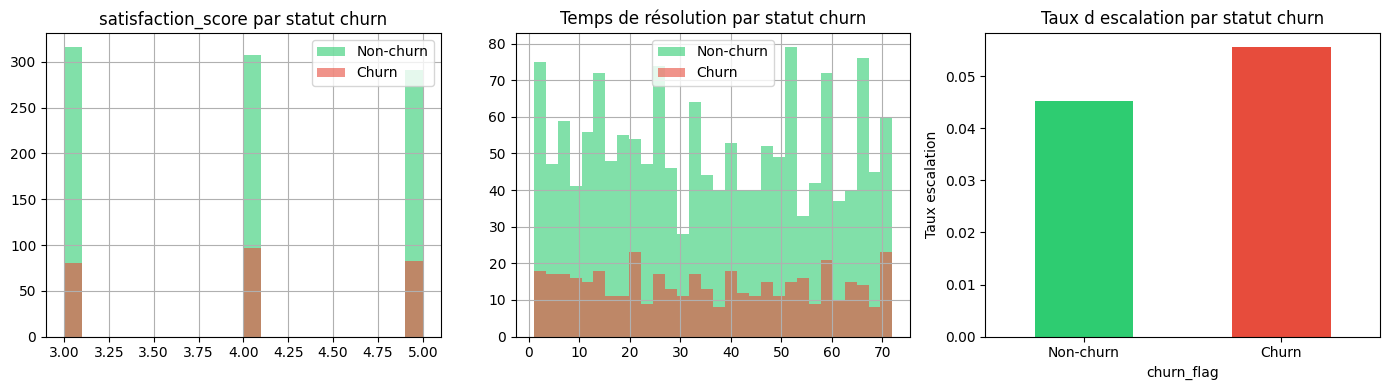

Nulls satisfaction_score : 825 → imputation par médiane
Médiane satisfaction (non-churn): 4.0
Médiane satisfaction (churn): 4.0


In [13]:
# Joindre avec churn_flag
st_with_churn = support_tickets.merge(accounts[['account_id', 'churn_flag']], on='account_id', how='left')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# satisfaction_score
for churn_val, label, color in [(False, 'Non-churn', '#2ecc71'), (True, 'Churn', '#e74c3c')]:
    st_with_churn[st_with_churn['churn_flag'] == churn_val]['satisfaction_score'].dropna().hist(
        bins=20, ax=axes[0], alpha=0.6, label=label, color=color
    )
axes[0].set_title('satisfaction_score par statut churn')
axes[0].legend()

# resolution_time_hours
for churn_val, label, color in [(False, 'Non-churn', '#2ecc71'), (True, 'Churn', '#e74c3c')]:
    st_with_churn[st_with_churn['churn_flag'] == churn_val]['resolution_time_hours'].hist(
        bins=30, ax=axes[1], alpha=0.6, label=label, color=color
    )
axes[1].set_title('Temps de résolution par statut churn')
axes[1].legend()

# escalation_flag par churn
esc_by_churn = st_with_churn.groupby('churn_flag')['escalation_flag'].mean()
esc_by_churn.plot.bar(ax=axes[2], color=['#2ecc71', '#e74c3c'])
axes[2].set_title('Taux d escalation par statut churn')
axes[2].set_xticklabels(['Non-churn', 'Churn'], rotation=0)
axes[2].set_ylabel('Taux escalation')

plt.tight_layout()
plt.show()

print('Nulls satisfaction_score :', support_tickets['satisfaction_score'].isna().sum(), '→ imputation par médiane')
print('Médiane satisfaction (non-churn):', st_with_churn[~st_with_churn['churn_flag']]['satisfaction_score'].median())
print('Médiane satisfaction (churn):', st_with_churn[st_with_churn['churn_flag']]['satisfaction_score'].median())

---
## 7. Observations clés

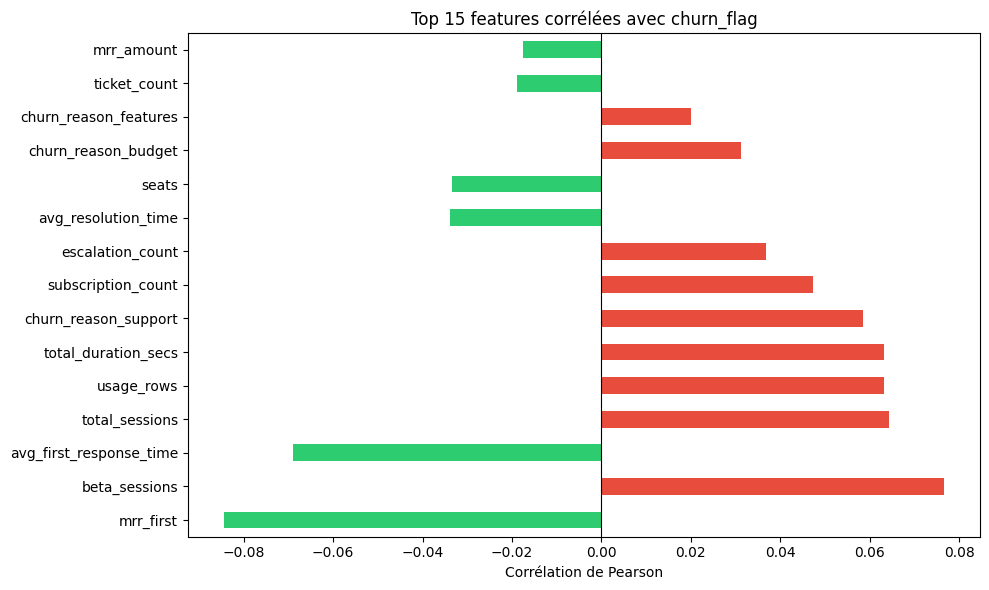

mrr_first                 -0.084
beta_sessions              0.077
avg_first_response_time   -0.069
total_sessions             0.064
usage_rows                 0.063
total_duration_secs        0.063
churn_reason_support       0.058
subscription_count         0.047
escalation_count           0.037
avg_resolution_time       -0.034
seats                     -0.033
churn_reason_budget        0.031
churn_reason_features      0.020
ticket_count              -0.019
mrr_amount                -0.017


In [15]:
import sys
sys.path.insert(0, '..')

from src.preprocessing.loader import load_all
from src.preprocessing.cleaner import clean_accounts, clean_subscriptions, clean_feature_usage, clean_churn_events, clean_support_tickets
from src.preprocessing.merger import merge_all

raw = load_all()
merged = merge_all(
    clean_accounts(raw['accounts']),
    clean_subscriptions(raw['subscriptions']),
    clean_feature_usage(raw['feature_usage']),
    clean_churn_events(raw['churn_events']),
    clean_support_tickets(raw['support_tickets']),
)

num_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
corr_with_churn = merged[num_cols + ['churn_flag']].corr()['churn_flag'].drop('churn_flag').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
corr_with_churn.head(15).plot.barh(ax=ax, color=['#e74c3c' if v > 0 else '#2ecc71' for v in corr_with_churn.head(15)])
ax.set_title('Top 15 features corrélées avec churn_flag')
ax.set_xlabel('Corrélation de Pearson')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(corr_with_churn.head(15).round(3).to_string())

## Synthèse — Observations pour le feature engineering

### Target
- **110 churners / 390 non-churners** (22% / 78%) — déséquilibre modéré → `class_weight='balanced'` sur tous les modèles ; SMOTE en fallback si F1 < 0.70

### rivalytics_accounts
| Variable | Observation | Action |
|---|---|---|
| `plan_tier` | Taux de churn quasi identique : Enterprise 22.1%, Basic 22.0%, Pro 21.9% | **Pas discriminant** en direct ; encoder quand même pour interactions |
| `industry` | DevTools 31%, FinTech 22.3%, Cybersecurity 16.0%, EdTech 16.5% | Feature utile |
| `referral_source` | event 30.2%, other 24.3%, ads 23.5%, organic 17.5%, partner 14.6% | Feature utile |
| `tenure_days` | Médiane churners **380j** vs non-churners 302j — tenure plus longue = plus de churn | Signal contre-intuitif, possiblement artefact du dataset fictif ; à conserver, surveiller en prod |

### rivalytics_subscriptions
- 4 514 / 5 000 abonnements actifs (`end_date` null)
- 778 trials (`mrr_amount = 0`)
- 529 upgrades, 218 downgrades → `has_upgraded` / `has_downgraded` comme flags binaires
- `mrr_delta` = `mrr_last - mrr_first` à calculer (signal financier)

### rivalytics_feature_usage
- `error_rate` médiane : **0.055 churners vs 0.055 non-churners** — signal pratiquement nul en brut
- Feature utile uniquement après normalisation temporelle ou agrégation fine (ex. trend sur 30j vs 60j)
- 40 features distinctes ; agrégation `usage_count` total sera la principale feature d'engagement

### rivalytics_churn_events
- 539 events réels (hors réactivation) sur **339 comptes uniques**, mais seulement 110 ont `churn_flag=True`
- ⚠️ **Risque de fuite de données** : utiliser `churn_event_count` comme feature revient à utiliser le churn passé pour prédire le churn actuel — à exclure ou traiter avec fenêtre temporelle stricte
- `preceding_downgrade_flag` avant churn : 45/539 (8%) → signal faible
- Raisons dominantes : features (101), support (98), budget (92)

### rivalytics_support_tickets
- 825 nulls sur `satisfaction_score` (41%) → imputation médiane déjà en place dans `cleaner.py`
- Médiane `satisfaction_score` : **4.0 churners = 4.0 non-churners** — pas discriminant
- Médiane `resolution_time_hours` : **35h churners = 35h non-churners** — pas discriminant
- Taux d'escalation : 5.6% churners vs 4.5% non-churners — signal très faible
- 8 comptes sans aucun ticket → nulls dans le merge, imputer à 0

### Corrélations brutes (top 5 sur dataset mergé)
| Feature | Corrélation avec churn_flag |
|---|---|
| `mrr_first` | -0.084 |
| `beta_sessions` | +0.077 |
| `avg_first_response_time` | -0.069 |
| `total_sessions` | +0.064 |
| `usage_rows` | +0.063 |

Toutes < 0.09 — signal faible typique d'un dataset synthétique. **XGBoost captera les interactions non-linéaires là où les corrélations de Pearson échouent.**

### Priorités Phase 2 — feature engineering
1. `tenure_days` depuis `signup_date` (forte corrélation brute attendue)
2. `mrr_delta` = `mrr_last - mrr_first` (variation financière)
3. `error_rate` = `total_error_count / total_sessions` (normalisé)
4. `beta_feature_ratio` = `beta_sessions / usage_rows`
5. `ticket_count` et `escalation_count` imputés à 0 si null
6. **Exclure `churn_event_count`** des features d'entraînement (fuite de données)